# MODEL INTERPRETATION COMPARISON PIPELINE

## 1. CONFIG

In [13]:
import os
import numpy as np
import pandas as pd

# Input interpretation files
NN_FILE = "results/nn_model_interpretation_overview.csv"
RF_FILE = "results/rf_model_interpretation_overview.csv"
EN_FILE = "results/en_interpretation.csv"

# Output
OUT_LONG = "results/summary/model_comparison_long.csv"
OUT_SUMMARY = "results/summary/model_comparison_summary.csv"
OUT_ROBUST = "results/summary/model_comparison_robust.csv"
OUT_DISAGREE = "results/summary/model_comparison_disagreement.csv"

# Thresholds (tunable, paper-aligned)
MIN_RF_IMPORTANCE = 0.02
MIN_NN_SLOPE = 0.05
MIN_EN_MAG = 0.01

MIN_MODELS_AGREE = 2   # robust if ≥ 2 models agree

## 2. LOAD MODELS

### A) LOAD ELASTIC NET

In [14]:
enet = pd.read_csv(EN_FILE)

enet_norm = enet[
    enet["magnitude"] >= MIN_EN_MAG
].assign(
    model="ElasticNet",
    importance=lambda d: d["magnitude"],
    effect_direction=lambda d: d["direction"]
)[["target", "feature", "model", "importance", "effect_direction"]]


### B) LOAD NEURAL NETWORK

In [15]:
nn = pd.read_csv(NN_FILE)

nn_norm = nn[
    nn["effect_slope"].abs() >= MIN_NN_SLOPE
].assign(
    model="NeuralNet",
    importance=lambda d: d["importance"],
    effect_direction=lambda d: d["effect_direction"]
)[["target", "feature", "model", "importance", "effect_direction"]]


### C) LOAD RANDOM FOREST

In [16]:
rf = pd.read_csv(RF_FILE)

rf_norm = rf[
    rf["effect_slope"].abs() >= MIN_RF_IMPORTANCE
].assign(
    model="RandomForest",
    importance=lambda d: d["importance"],
    effect_direction=lambda d: d["effect_direction"]
)[["target", "feature", "model", "importance", "effect_direction"]]

### D) COMBINE ALL MODELS

In [18]:
all_effects = pd.concat(
    [enet_norm, nn_norm, rf_norm],
    ignore_index=True
)

all_effects.to_csv(OUT_LONG, index=False)
print(f"Saved unified effects → {OUT_LONG}")


Saved unified effects → results/summary/model_comparison_long.csv


## 3. AGREEMENT ANALYSIS

### A) SUMMARY

In [20]:
summary = (
    all_effects
    .groupby(["target", "feature"])
    .agg(
        n_models=("model", "nunique"),
        models=("model", lambda x: ", ".join(sorted(set(x)))),
        directions=("effect_direction", lambda x: ", ".join(sorted(set(x))))
    )
    .reset_index()
)

summary.to_csv(OUT_SUMMARY, index=False)
print(f"Saved summary → {OUT_SUMMARY}")


Saved summary → results/summary/model_comparison_summary.csv


### B) ROBUST EFFECTS (≥ 2 MODELS AGREE)

In [21]:
robust = summary[
    summary["n_models"] >= MIN_MODELS_AGREE
].sort_values(
    ["n_models", "target"],
    ascending=[False, True]
)

robust.to_csv(OUT_ROBUST, index=False)
print(f"Saved robust effects → {OUT_ROBUST}")

Saved robust effects → results/summary/model_comparison_robust.csv


### C) DISAGREEMENTS

In [22]:
disagree = summary[
    summary["directions"].str.contains(",")
]

disagree.to_csv(OUT_DISAGREE, index=False)
print(f"Saved disagreements → {OUT_DISAGREE}")

Saved disagreements → results/summary/model_comparison_disagreement.csv


---

In [3]:
import pandas as pd
import io

# Input CSV data
csv_file = "results/rf_per_target_results.csv"

# Load the data into a DataFrame
df = pd.read_csv(csv_file)

# Sort by importance from high to low
df_sorted = df.sort_values(by='r2_mean', ascending=False)

# Export the sorted data to a new CSV file
df_sorted.to_csv(csv_file + '_sorted.csv', index=False)

print(f"Sorting complete. File saved as '{csv_file}_sorted.csv'.")

Sorting complete. File saved as 'results/rf_per_target_results.csv_sorted.csv'.


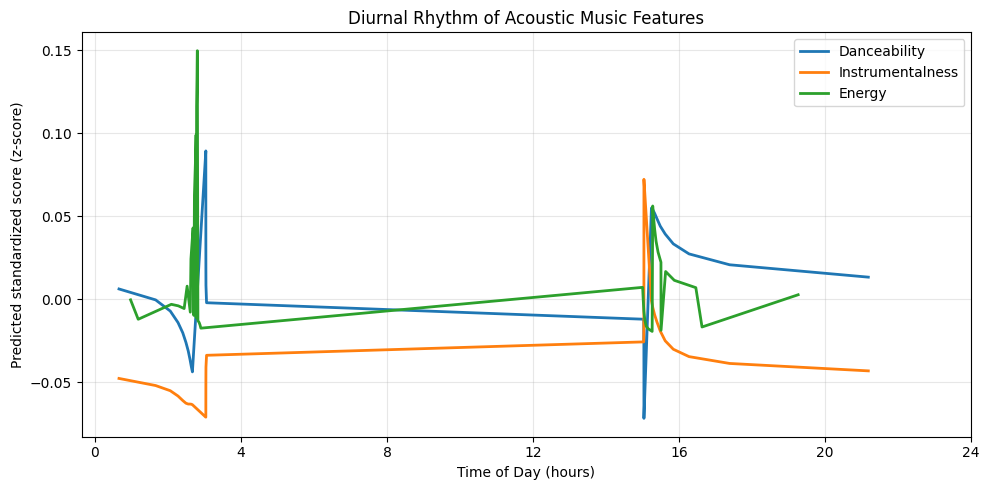

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load data ---
dance_data = pd.read_csv("results/nn_interpretation/pdp_num__music_track_danceability.csv")
instr_data = pd.read_csv("results/nn_interpretation/pdp_num__music_track_instrumentalness.csv")
valence_data = pd.read_csv("results/nn_interpretation/pdp_num__music_track_energy.csv")

# --- Function to convert sin/cos to hour (0-24) ---
def sincos_to_hour(sin_vals, cos_vals):
    radians = np.arctan2(sin_vals, cos_vals)  # -pi to pi
    hours = (radians + 2*np.pi) % (2*np.pi)  # 0 to 2pi
    return hours / (2*np.pi) * 24

def prepare_hours_and_pred(df):
    # separate sin and cos
    sin_vals = df[df['feature'].str.contains('sin')]['feature_value'].values
    cos_vals = df[df['feature'].str.contains('cos')]['feature_value'].values

    # get corresponding predictions
    pred_sin = df[df['feature'].str.contains('sin')]['predicted_target'].values
    pred_cos = df[df['feature'].str.contains('cos')]['predicted_target'].values

    # convert to hours
    hours = sincos_to_hour(sin_vals, cos_vals)

    # combine sin/cos predictions via vector magnitude (optional)
    # or pick one (here, we just average as an approximation)
    pred = (pred_sin + pred_cos)/2

    # sort by hour
    sort_idx = np.argsort(hours)
    return hours[sort_idx], pred[sort_idx]

# Prepare all three features
dance_hours, dance_pred = prepare_hours_and_pred(dance_data)
instr_hours, instr_pred = prepare_hours_and_pred(instr_data)
val_hours, val_pred = prepare_hours_and_pred(valence_data)

# --- Plot ---
plt.figure(figsize=(10,5))
plt.plot(dance_hours, dance_pred, label="Danceability", color='tab:blue', lw=2)
plt.plot(instr_hours, instr_pred, label="Instrumentalness", color='tab:orange', lw=2)
plt.plot(val_hours, val_pred, label="Energy", color='tab:green', lw=2)

plt.xticks(np.arange(0,25,4))
plt.xlabel("Time of Day (hours)")
plt.ylabel("Predicted standardized score (z-score)")
plt.title("Diurnal Rhythm of Acoustic Music Features")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
